# TFR-Based MVPA: Generalization Across Time (GAT)

**Conditions A vs D — Within-Subject Classification**

This notebook classifies neural conditions using time-frequency power as features,
rather than raw voltage. At each time point, the classifier receives power in up to 4 frequency
bands (Delta, Theta, Alpha, Beta) × 32 electrodes = 128 features

Pipeline:
1. Load Aurnhammer 2021 data → build MNE Epochs
2. *(Optional)* Subtract ERP for induced-only or evoked-only power
3. Compute per-trial Morlet TFR (2–30 Hz)
4. Average power within 4 canonical frequency bands
5. Run GAT classification (LogisticRegression + StratifiedKFold)
6. Visualize grand-average GAT matrix

## 1 — Imports & Configuration

In [3]:
import os
import datetime
import numpy as np
import pandas as pd
import mne
import matplotlib.pyplot as plt
from collections import OrderedDict
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score


# Downsampling
# True  -> decimate TFR output from 500 Hz to 100 Hz (recommended)
# False -> keep original 500 Hz temporal resolution (very computationally heavy)
DOWNSAMPLE = True

# Keep total power for now
POWER_MODE = 'total'


# TFR parameters (same as in accompanying TFA notebook)
freqs    = np.arange(2, 31, 1)   # 2–30 Hz in 1-Hz steps (29 bins)
n_cycles = freqs / 1.2           # frequency-adaptive wavelet widths
decim    = 5 if DOWNSAMPLE else 1  # temporal decimation during TFR

# Frequency bands options
# a subset of the available frequency bands can be chosen as input for the MVPA
# as delta + theta perform the best in diagonal decoding, only they will be selected
# -> implementation that was followed in the thesis
BANDS = OrderedDict([
    ('Delta', (2, 3)),    # Delta: 2–3 Hz  (standard: 1–4 Hz, our min is 2)
    ('Theta', (4, 7)),    # Theta: 4–7 Hz  (standard: 4–8 Hz)
   # ('Alpha', (8, 12)),   # Alpha: 8–12 Hz (standard: 8–13 Hz) #commented out for performance reasons
   # ('Beta',  (13, 30)),  # Beta: 13–30 Hz (standard: 13–30 Hz) #commented out for performance reasons
])

# Classifier parameters
c        = 0.001 #regularization strength (inverse)
n_splits = 5
cv       = StratifiedKFold(n_splits=n_splits)
clf      = LogisticRegression(penalty='l2', C=c, solver='liblinear', max_iter=1000)


# For logging
clf_name = 'LogReg' # for logging
# Conditions 
cond_1, cond_2 = 'A', 'D'
conditions = f'{cond_1}vs{cond_2}'

# Data path, supply the path to the CAPExp.csv file from Aurnhammer et al. (2021)
csv_path = '/Users/davidflak/Documents/Internship MVPA 2025 Brouwer/Aurnhammer data/PLOSONE21lmerERP_ObservedData/CAPExp.csv'

# Sampling rate
sfreq = 500


print(f'Downsample:   {DOWNSAMPLE} (decim={decim})')
print(f'Frequencies:  {freqs[0]}–{freqs[-1]} Hz ({len(freqs)} bins)')
print(f'Bands:        {list(BANDS.keys())}')
print(f'Conditions:   {conditions}')
print(f'Classifier:   {clf_name} (C={c}, cv={n_splits})')

Downsample:   True (decim=5)
Frequencies:  2–30 Hz (29 bins)
Bands:        ['Delta', 'Theta']
Conditions:   AvsD
Classifier:   LogReg (C=0.001, cv=5)


## 2 — Data Loading & Helper Functions

In [4]:
# Load data
df = pd.read_csv(csv_path)
print(f'Loaded {len(df)} rows, {df["Subject"].nunique()} subjects')

# 32 EEG channels
eeg_channels = [
    'Fp1','Fp2','F7','F3','Fz','F4','F8','FC5',
    'FC1','FC2','FC6','T7','C3','Cz','C4','T8',
    'TP9','CP5','CP1','CP2','CP6','TP10','P7','P3',
    'Pz','P4','P8','PO9','O1','Oz','O2','PO10'
]

# MNE Info object
info = mne.create_info(ch_names=eeg_channels, sfreq=sfreq, ch_types='eeg')
info.set_montage('standard_1020', on_missing='ignore')


# Create mne.EpochsArray object to make full use of MNE wavelet functions
def make_epochs(df_subj_cond):
    """Convert a DataFrame slice (one subject, one condition) into an MNE EpochsArray."""
    epochs_data = []
    for trial, df_trial in df_subj_cond.groupby('TrialNum'):
        data = df_trial[eeg_channels].to_numpy().T  # (n_channels, n_times)
        epochs_data.append(data)
    epochs_data = np.array(epochs_data)  # (n_trials, n_channels, n_times)
    events = np.array([[i, 0, 1] for i in range(len(epochs_data))])
    tmin = df_subj_cond['Timestamp'].iloc[0] / 1000.0
    epochs = mne.EpochsArray(
        epochs_data, info, events=events,
        event_id={'stim': 1}, tmin=tmin, verbose=False
    )
    return epochs


# helper function to convert individual frequency power estimates to frequency band power values -> dimensionality reduction
def average_power_in_bands(tfr_data, freqs, bands):
    """
    Average TFR power within frequency bands.

    Parameters
    ----------
    tfr_data : ndarray, shape (n_trials, n_channels, n_freqs, n_times)
    freqs    : ndarray, shape (n_freqs,)
    bands    : OrderedDict, {band_name: (fmin, fmax)} — inclusive ranges, no overlap

    Returns
    -------
    band_data : ndarray, shape (n_trials, n_channels, n_bands, n_times)
    """
    band_data = []
    for name, (fmin, fmax) in bands.items():
        freq_mask = (freqs >= fmin) & (freqs <= fmax)
        band_power = tfr_data[:, :, freq_mask, :].mean(axis=2)  # average across freqs in band
        band_data.append(band_power)
    return np.stack(band_data, axis=2)  # (n_trials, n_channels, n_bands, n_times)


print('Helper functions defined.')
print(f'Band definitions: {dict(BANDS)}')

Loaded 2828700 rows, 40 subjects
Helper functions defined.
Band definitions: {'Delta': (2, 3), 'Theta': (4, 7)}


## 3 — TFR-MVPA GAT Classification

In [8]:
%%time

# Create folder to save results 
os.makedirs('GAT_Results', exist_ok=True)

# Checkpoint file (resumes from here after code crashes)
checkpoint_file = f'GAT_Results/gat_TFR_{conditions}_{clf_name}_C{c}_cv{n_splits}_{POWER_MODE}_checkpoint.npz'

# Timestamped final file
timestamp = datetime.datetime.now().strftime('%Y%m%d-%H%M%S')
final_file = f'GAT_Results/gat_TFR_{conditions}_{clf_name}_C{c}_cv{n_splits}_{POWER_MODE}_{timestamp}.npz'

# Try to resume from checkpoint
gat_matrices = []
start_idx = 0
if os.path.exists(checkpoint_file):
    checkpoint = np.load(checkpoint_file, allow_pickle=True)
    gat_matrices = list(checkpoint['gat_matrices'])
    start_idx = int(checkpoint['last_subject']) + 1
    print(f'Resuming from subject index {start_idx} (found checkpoint).')

n_bands = len(BANDS)
n_ch = len(eeg_channels)
n_features = n_ch * n_bands  # 32 × 4 = 128
print(f'Features per time point: {n_ch} channels × {n_bands} bands = {n_features}')




# Main loop over subjects
for i, (subj, df_sub) in enumerate(df.groupby('Subject')):
    if i < start_idx: #resume at last subject if checkpoint was found
        continue
    if i >= 3: # Sanity check, reduce for early stop before all subjects have been processed
        break


    # Check if both conditions exist for this subject
    if cond_1 not in df_sub['Condition'].values or cond_2 not in df_sub['Condition'].values:
        print(f'  Subject {subj}: missing condition, skipping.')
        continue

    print(f'Subject {subj} (index {i}) ... ', end='')

    # 1. Build epochs
    epochs_1 = make_epochs(df_sub[df_sub['Condition'] == cond_1])
    epochs_2 = make_epochs(df_sub[df_sub['Condition'] == cond_2])


    # 2. Compute per-trial TFR (average=False! individual trials need to be preserved to train classifiers, unlike for the topological maps)
    tfr_1 = mne.time_frequency.tfr_morlet(
        epochs_1, freqs=freqs, n_cycles=n_cycles,
        use_fft=True, return_itc=False,
        decim=decim, n_jobs=-1, average=False, verbose=False
    )
    tfr_2 = mne.time_frequency.tfr_morlet(
        epochs_2, freqs=freqs, n_cycles=n_cycles,
        use_fft=True, return_itc=False,
        decim=decim, n_jobs=-1, average=False, verbose=False
    )

    # 4. Get power data: (n_trials, n_channels, n_freqs, n_times)
    power_1 = tfr_1.data
    power_2 = tfr_2.data

    # 5. Average within frequency bands → (n_trials, n_channels, n_bands, n_times)
    band_1 = average_power_in_bands(power_1, freqs, BANDS)
    band_2 = average_power_in_bands(power_2, freqs, BANDS)

    # 6. Reshape: flatten channels × bands -> features
    #    (n_trials, n_channels, n_bands, n_times) -> (n_trials, n_channels*n_bands, n_times)
    n1, _, _, n_t = band_1.shape
    n2 = band_2.shape[0]
    X1 = band_1.reshape(n1, n_features, n_t)
    X2 = band_2.reshape(n2, n_features, n_t)

    # 7. Pool data + create labels
    X = np.vstack([X1, X2])
    y = np.hstack([np.zeros(n1), np.ones(n2)])
    n_trials, _, n_times = X.shape

    if i == start_idx:
        print(f'\n  Pooled data shape: {X.shape} (trials, features, time_points)')
        # Store times for visualization later
        times = tfr_1.times

    # 8. GAT classification loop
    gat = np.zeros((n_times, n_times))
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        for t_train in range(n_times):
            clf.fit(X_train[:, :, t_train], y_train)

            for t_test in range(n_times):
                y_proba = clf.predict_proba(X_test[:, :, t_test])[:, 1]
                auc = roc_auc_score(y_test, y_proba)
                gat[t_train, t_test] += auc

    # Average over folds
    gat /= n_splits
    gat_matrices.append(gat)
    print(f'done (mean diagonal AUC: {np.diag(gat).mean():.3f})')

    # Save checkpoint
    np.savez(checkpoint_file,
             gat_matrices=np.array(gat_matrices, dtype=object),
             last_subject=i,
             times=times)

print(f'\nCompleted {len(gat_matrices)} subjects.')

Features per time point: 32 channels × 2 bands = 64
Subject 1 (index 0) ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").

  Pooled data shape: (58, 64, 140) (trials, features, time_points)
done (mean diagonal AUC: 0.577)
Subject 3 (index 1) ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done (mean diagonal AUC: 0.486)
Subject 5 (index 2) ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done (mean diagonal AUC: 0.556)

Completed 3 subjects.
CPU times: user 10min 21s, sys: 19.5 s, total: 10min 40s
Wall time: 12min 31s


## 4 — Save Results

In [29]:
# Save final results with timestamped filename
np.savez(final_file,
         gat_matrices=np.array(gat_matrices, dtype=object),
         times=times,
         bands=list(BANDS.keys()),
         power_mode=POWER_MODE,
         downsample=DOWNSAMPLE)
print(f'Saved final results to {final_file}')
print(f'  {len(gat_matrices)} GAT matrices, shape: {gat_matrices[0].shape}')

Saved final results to GAT_Results/gat_TFR_AvsD_LogReg_C0.001_cv5_total_20260506-184955.npz
  40 GAT matrices, shape: (140, 140)


## 5 — Visualization: Grand-Average GAT Matrix

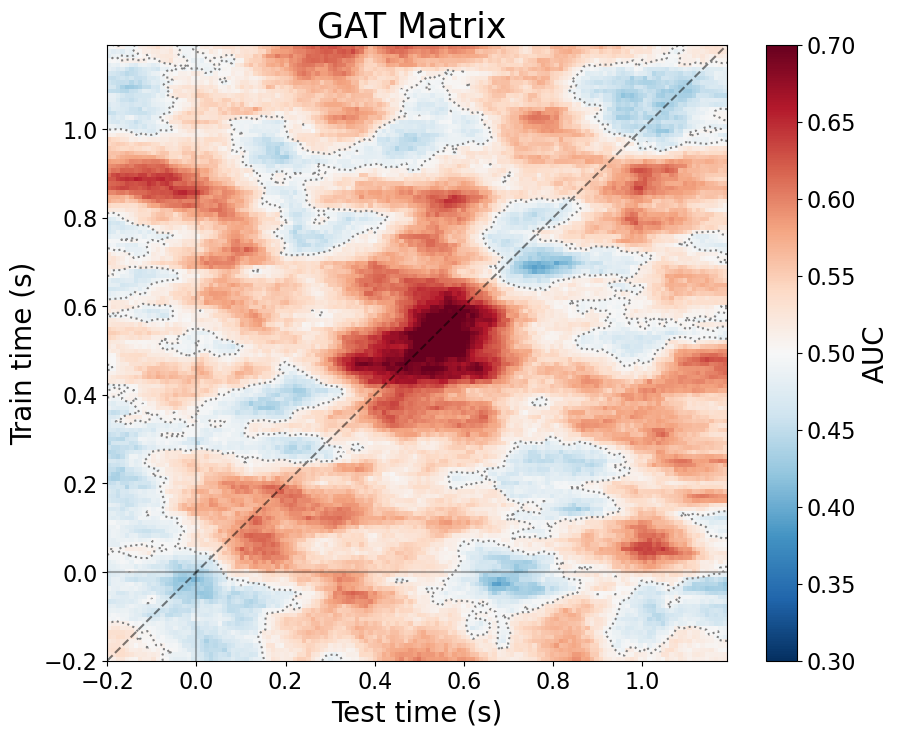

In [9]:
# === GRAND AVERAGE VISUALIZATION ===

# Ensure data is stacked and explicitly cast to float to avoid object-dtype errors (imshow requirement)
grand_avg_gat = np.stack(gat_matrices).astype(float).mean(axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 8))
im = ax.imshow(grand_avg_gat, origin='lower', aspect='auto', 
               extent=[times[0], times[-1], times[0], times[-1]], 
               cmap='RdBu_r', vmin=0.3, vmax=0.7)

ax.plot([times[0], times[-1]], [times[0], times[-1]], 'k--', alpha=0.5)
ax.axhline(0, color='k', alpha=0.3)
ax.axvline(0, color='k', alpha=0.3)
ax.contour(grand_avg_gat, levels=[0.5], extent=[times[0], times[-1], times[0], times[-1]], colors='gray', linestyles='dotted')

# 1. Increase axis label sizes
ax.set_xlabel('Test time (s)', fontsize=20)
ax.set_ylabel('Train time (s)', fontsize=20)

# 2. Increase title size
ax.set_title(f'GAT Matrix ', fontsize=25)

# 3. Increase the tick labels (the numbers on the x and y axes)
ax.tick_params(axis='both', labelsize=16)

# 4. Increase colorbar label and colorbar tick labels
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('AUC', fontsize=20)
cbar.ax.tick_params(labelsize=16) 

plt.show()

## 6 — Diagonal-Only MVPA with Band-Combination Comparison

This cell runs a diagonal-only classification (train and test at the same time point).
It is much faster than the full GAT and useful to investigate the performance of different frequency band combinations as input for the classifiers

BAND_COMBOS: A list of tuples. Each tuple names the frequency bands used as features in one
classification run. All runs are plotted together in Cell 6.



In [11]:
%%time

from sklearn.preprocessing import StandardScaler
# ============================================================
# CONFIGURATION: which band combinations to compare
# ============================================================
BANDS = OrderedDict([
    ('Delta', (2, 3)),    # Delta: 2–3 Hz  (standard: 1–4 Hz, our min is 2)
    ('Theta', (4, 7)),    # Theta: 4–7 Hz  (standard: 4–8 Hz)
    ('Alpha', (8, 12)),   # Alpha: 8–12 Hz (standard: 8–13 Hz) 
    ('Beta',  (13, 30)),  # Beta: 13–30 Hz (standard: 13–30 Hz) 
])

BAND_COMBOS = [
    ('Delta', 'Theta', 'Alpha', 'Beta'),
    ('Delta', 'Theta', 'Beta'),
    ('Delta', 'Theta'),

]

# Results folder
os.makedirs('GAT_Results', exist_ok=True)

# Build a label for each combo
combo_labels = ['+'.join(combo) for combo in BAND_COMBOS]
print(f'Band combinations to evaluate: {combo_labels}')
print(f'Power mode: {POWER_MODE}')

# Storage: dict  combo_label -> list of 1D arrays (one per subject)
diag_results = {label: [] for label in combo_labels}
diag_times = None  # filled on first subject

# Checkpoint file for diagonal runs
diag_checkpoint = f'GAT_Results/diag_TFR_{conditions}_{clf_name}_C{c}_cv{n_splits}_{POWER_MODE}_checkpoint.npz'

# Try to resume from checkpoint
diag_start_idx = 0
if os.path.exists(diag_checkpoint):
    ckpt = np.load(diag_checkpoint, allow_pickle=True)
    diag_results = {k: list(v) for k, v in ckpt['diag_results'].item().items()}
    diag_start_idx = int(ckpt['last_subject']) + 1
    diag_times = ckpt['times']
    print(f'Resuming diagonal from subject index {diag_start_idx} (found checkpoint).')

n_ch = len(eeg_channels)

# === Main loop over subjects ===
for i, (subj, df_sub) in enumerate(df.groupby('Subject')):
    if i < diag_start_idx:
        continue
    if i >= 40:
        break

    # ---- SANITY CHECK: uncomment next line to run only 1 subject ----
    #if i >= 5: break

    # Check both conditions exist
    if cond_1 not in df_sub['Condition'].values or cond_2 not in df_sub['Condition'].values:
        print(f'  Subject {subj}: missing condition, skipping.')
        continue

    print(f'Subject {subj} (index {i}) ... ', end='')

    # 1. Build epochs
    epochs_1 = make_epochs(df_sub[df_sub['Condition'] == cond_1])
    epochs_2 = make_epochs(df_sub[df_sub['Condition'] == cond_2])


    # 2. Compute per-trial TFR (once — reused for all combos)
    tfr_1 = mne.time_frequency.tfr_morlet(
        epochs_1, freqs=freqs, n_cycles=n_cycles,
        use_fft=True, return_itc=False,
        decim=decim, n_jobs=-1, average=False, verbose=False
    )
    tfr_2 = mne.time_frequency.tfr_morlet(
        epochs_2, freqs=freqs, n_cycles=n_cycles,
        use_fft=True, return_itc=False,
        decim=decim, n_jobs=-1, average=False, verbose=False
    )
    power_1 = tfr_1.data  # (n_trials, n_channels, n_freqs, n_times)
    power_2 = tfr_2.data

    if diag_times is None:
        diag_times = tfr_1.times

    # 3. Loop over band combos
    for combo, label in zip(BAND_COMBOS, combo_labels):
        # Select only the bands in this combo
        combo_bands = OrderedDict([(b, BANDS[b]) for b in combo])
        n_bands_combo = len(combo_bands)
        n_features_combo = n_ch * n_bands_combo

        # Average within selected bands
        band_1 = average_power_in_bands(power_1, freqs, combo_bands)
        band_2 = average_power_in_bands(power_2, freqs, combo_bands)

        # Reshape to (n_trials, n_features, n_times)
        n1, _, _, n_t = band_1.shape
        n2 = band_2.shape[0]
        X1 = band_1.reshape(n1, n_features_combo, n_t)
        X2 = band_2.reshape(n2, n_features_combo, n_t)

        # Pool + labels
        X = np.vstack([X1, X2])
        y = np.hstack([np.zeros(n1), np.ones(n2)])
        n_trials, _, n_times_combo = X.shape

        # Diagonal-only classification
        diag_auc = np.zeros(n_times_combo)
        for train_idx, test_idx in cv.split(X, y):
            X_train, X_test = X[train_idx], X[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]

            for t in range(n_times_combo):
                #normalization step to improve classifier stability
                scaler = StandardScaler() 
                X_train_t = scaler.fit_transform(X_train[:, :, t])
                X_test_t = scaler.transform(X_test[:, :, t])

                clf.fit(X_train_t, y_train)
                y_proba = clf.predict_proba(X_test_t)[:, 1]
                auc = roc_auc_score(y_test, y_proba)
                diag_auc[t] += auc

        diag_auc /= n_splits
        diag_results[label].append(diag_auc)

    aucs_summary = ', '.join([f'{lbl}: {np.mean(diag_results[lbl][-1]):.3f}'
                              for lbl in combo_labels])
    print(f'done  (mean AUC: {aucs_summary})')

    # Save checkpoint
    np.savez(diag_checkpoint,
             diag_results=diag_results,
             last_subject=i,
             times=diag_times)

print(f'\nCompleted diagonal MVPA for {len(diag_results[combo_labels[0]])} subjects.')
print(f'Combos evaluated: {combo_labels}')

Band combinations to evaluate: ['Delta+Theta+Alpha+Beta', 'Delta+Theta+Beta', 'Delta+Theta']
Power mode: total
Subject 1 (index 0) ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").


python(76426) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76427) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76428) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76429) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76430) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76431) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76432) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
python(76433) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done  (mean AUC: Delta+Theta+Alpha+Beta: 0.589, Delta+Theta+Beta: 0.540, Delta+Theta: 0.533)
Subject 3 (index 1) ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done  (mean AUC: Delta+Theta+Alpha+Beta: 0.508, Delta+Theta+Beta: 0.503, Delta+Theta: 0.488)
Subject 5 (index 2) ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done  (mean AUC: Delta+Theta+Alpha+Beta: 0.542, Delta+Theta+Beta: 0.558, Delta+Theta: 0.561)
Subject 6 (index 3) ... NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
NOTE: tfr_morlet() is a legacy function. New code should use .compute_tfr(method="morlet").
done 

KeyboardInterrupt: 

## 7 — Diagonal AUC Line Plot: Band-Combination Comparison

Plots AUC over time for each band combination on a single figure.
Each combo is a differently-coloured line.

/var/folders/96/y54pdqb55gq2prn1kzbn6vbc0000gn/T/ipykernel_73957/696406091.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('tab10', len(combo_labels))


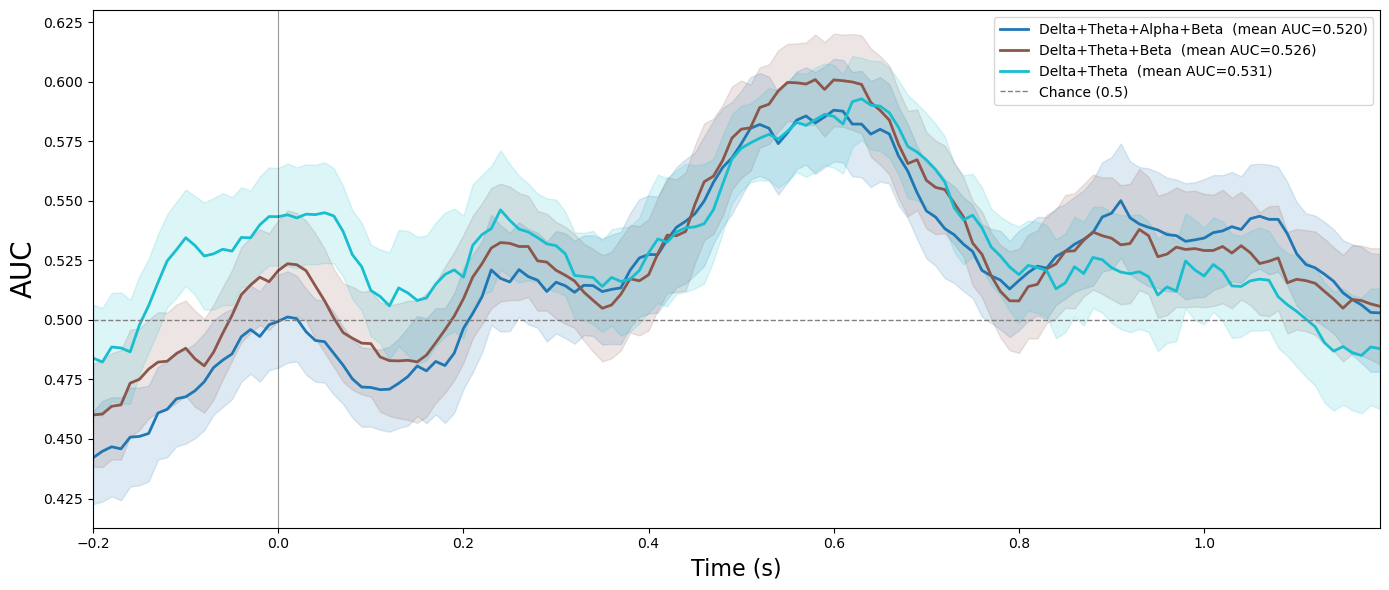


--- Diagonal AUC Summary ---
  Delta+Theta+Alpha+Beta  mean=0.5203  max=0.5881 (t=0.600s)
  Delta+Theta+Beta      mean=0.5260  max=0.6009 (t=0.580s)
  Delta+Theta           mean=0.5312  max=0.5928 (t=0.630s)


In [12]:
# Colour palette (extend if more combos needed)
import matplotlib.cm as cm

colors = cm.get_cmap('tab10', len(combo_labels))

fig, ax = plt.subplots(figsize=(14, 6))

for idx, label in enumerate(combo_labels):
    # Grand-average across subjects
    subject_curves = np.array(diag_results[label]).astype(float)
    grand_avg = subject_curves.mean(axis=0)
    sem = subject_curves.std(axis=0) / np.sqrt(len(subject_curves))  # standard error

    color = colors(idx)
    ax.plot(diag_times, grand_avg, color=color, linewidth=2,
            label=f'{label}  (mean AUC={grand_avg.mean():.3f})')
    ax.fill_between(diag_times, grand_avg - sem, grand_avg + sem,
                    color=color, alpha=0.15)

# Chance level
ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='Chance (0.5)')

# Stimulus onset
ax.axvline(x=0, color='k', linestyle='-', linewidth=0.8, alpha=0.4)

ax.set_xlabel('Time (s)', fontsize=16)
ax.set_ylabel('AUC', fontsize=20)

ax.legend(loc='upper right', fontsize=10)
ax.set_xlim(diag_times[0], diag_times[-1])

plt.tight_layout()
plt.savefig(f'GAT_Results/diag_TFR_{conditions}_{POWER_MODE}_bandcombos.png',
            dpi=150, bbox_inches='tight')
plt.show()

# Print summary table
print('\n--- Diagonal AUC Summary ---')
for label in combo_labels:
    subject_curves = np.array(diag_results[label]).astype(float)
    grand_avg = subject_curves.mean(axis=0)
    print(f'  {label:20s}  mean={grand_avg.mean():.4f}  '
          f'max={grand_avg.max():.4f} (t={diag_times[grand_avg.argmax()]:.3f}s)')